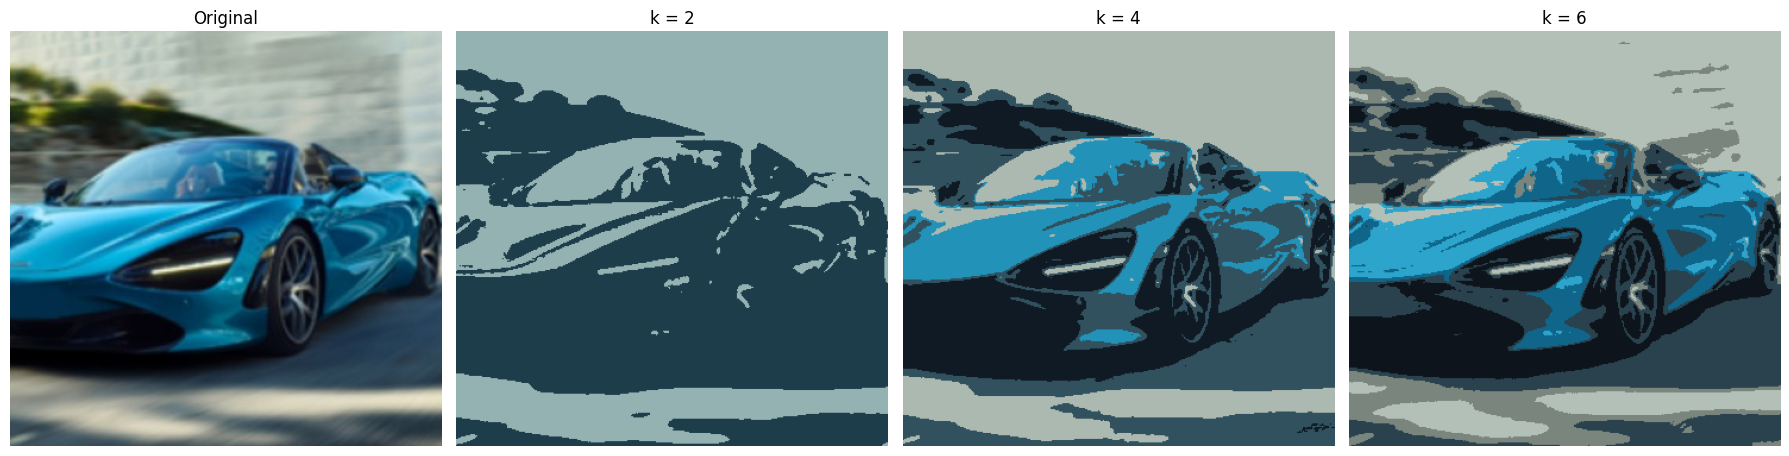


Colores promedio para k = 2:
[[ 30  61  75]
 [148 178 178]]

Colores promedio para k = 4:
[[ 34 146 185]
 [ 49  81  94]
 [ 15  26  36]
 [171 185 176]]

Colores promedio para k = 6:
[[179 192 183]
 [ 13  20  27]
 [ 45 164 204]
 [ 16 101 138]
 [122 133 126]
 [ 41  66  78]]


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Cargar imagen a color
img_path = 'mclaren720s.jpg'
imagen_bgr = cv2.imread(img_path, cv2.IMREAD_COLOR)

if imagen_bgr is None:
    raise ValueError("No se pudo cargar la imagen.")

# Conversión BGR a RGB
imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)

alto, ancho, canales = imagen_rgb.shape

# Imagen en matriz N x 3
pixeles = imagen_rgb.reshape((-1, 3))
pixeles = np.float32(pixeles)  # K-means requiere float32

# Criterios de parada
criterios = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)

# Valores de k a probar
valores_k = [2, 4, 6]

imagenes_segmentadas = []
colores_clusters = []

for k in valores_k:
    # Aplicar K-means
    compactness, labels, centros = cv2.kmeans(
        pixeles,
        k,
        None,
        criterios,
        10,
        cv2.KMEANS_RANDOM_CENTERS
    )

    # Centros a uint8
    centros = np.uint8(centros)
    colores_clusters.append(centros)

    # Reconstruir imagen usando los colores promedio
    imagen_segmentada = centros[labels.flatten()]
    imagen_segmentada = imagen_segmentada.reshape((alto, ancho, 3))
    imagenes_segmentadas.append(imagen_segmentada)

# ==============================
# Visualización comparativa
# ==============================

plt.figure(figsize=(18,6))

# Imagen original
plt.subplot(1, 4, 1)
plt.imshow(imagen_rgb)
plt.title("Original")
plt.axis('off')

# Imágenes segmentadas
for i, k in enumerate(valores_k):
    plt.subplot(1, 4, i+2)
    plt.imshow(imagenes_segmentadas[i])
    plt.title(f"k = {k}")
    plt.axis('off')

plt.tight_layout()
plt.show()

# ==============================
# Colores promedio de cada cluster
# ==============================

for i, k in enumerate(valores_k):
    print(f"\nColores promedio para k = {k}:")
    print(colores_clusters[i])